In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
%run ~/Dropbox/Nonlinear/Experiments/CODE/LABCodes/ComputeDelays.py

In [73]:
def compdelay(t,sig1,sig2,sig3,winlen=10):

    activechannelnames=[0]
    
    probedat=[timedata(ch) for ch in activechannelnames]
    PUMPdat=[timedata(ch) for ch in activechannelnames]
    bothdat=[timedata(ch) for ch in activechannelnames]
    
    probedat[0].time=t/1e3
    probedat[0].data=sig1
    
    PUMPdat[0].time=t/1e3
    PUMPdat[0].data=sig2
    
    bothdat[0].time=t/1e3
    bothdat[0].data=sig3
    
    tshift=Compute_single_delay(bothdat,probedat,PUMPdat,0,winlen)

    return tshift

In [74]:
dt=1e-4 #%ms
nt=1000
dt_shift=dt*.2

fPUMP=50 #%kHz
fprobe=500 #%kHz

t=np.arange(0,nt)*dt

per_pulse=21e-3 #in ms repetition rate of the high-f probe
nper_pulse=int(per_pulse/dt)
print(per_pulse-t[nper_pulse])
per_probe=1/fprobe
nper_probe=int(per_probe/dt)
print(per_probe-t[nper_probe])

sigPUMP=np.sin(2.*np.pi*fPUMP*t)

sigprobe_pulse=0.1*np.sin(2.*np.pi*fprobe*t[0:nper_probe])#one period of probe
sigprobe=np.zeros_like(t)
sigprobe_pert=np.zeros_like(t)

npulses=int(nt/nper_pulse)
tshift_true=np.arange(0,npulses+1)*dt_shift

ii=0
itstart=50
while itstart < nt:
    sigprobe[itstart:itstart+nper_probe]=sigprobe_pulse
    sigprobe_pert[itstart:itstart+nper_probe]=0.1*np.sin(2.*np.pi*fprobe*(t[0:nper_probe]+tshift_true[ii]))
    itstart=itstart+nper_pulse
    ii=ii+1


0.0
0.0


(0.08, 0.1)

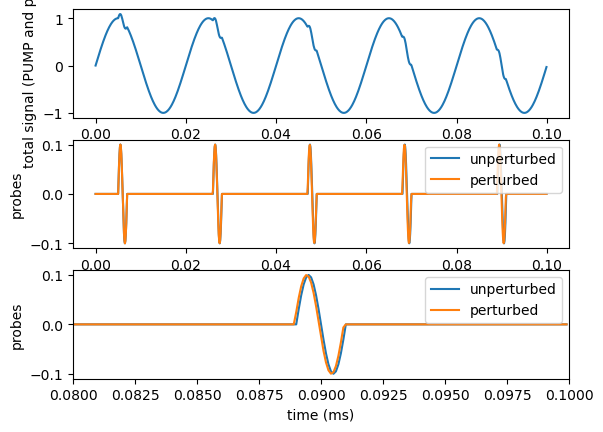

In [86]:
plt.figure()
plt.subplot(311)
plt.plot(t,sigPUMP+sigprobe_pert)
plt.xlabel('time (ms)')
plt.ylabel('total signal (PUMP and probe)')
plt.subplot(312)
plt.plot(t,sigprobe,label='unperturbed')
plt.plot(t,sigprobe_pert,label='perturbed')
plt.legend()
plt.xlabel('time (ms)')
plt.ylabel('probes')
plt.subplot(313)
plt.plot(t,sigprobe,label='unperturbed')
plt.plot(t,sigprobe_pert,label='perturbed')
plt.legend()
plt.xlabel('time (ms)')
plt.ylabel('probes')
plt.xlim([0.08,0.1])

#plt.xlim([0.08,0.09])

20


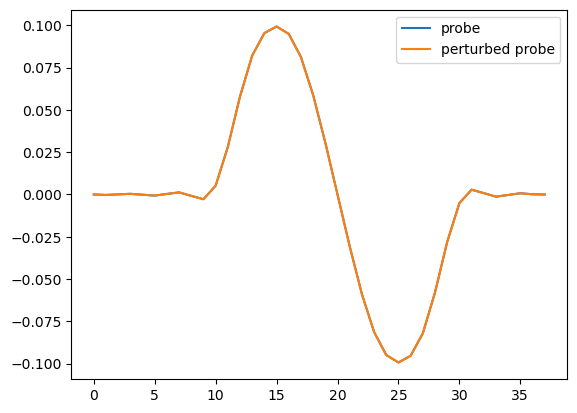

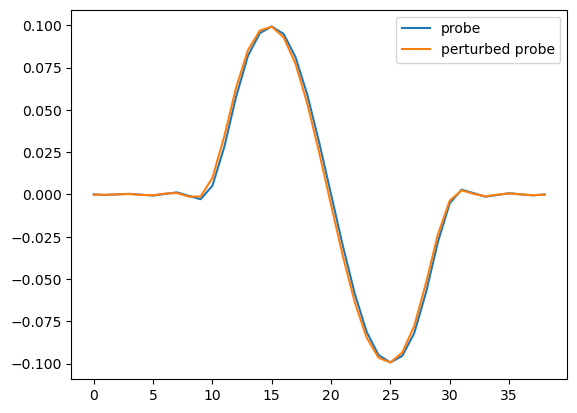

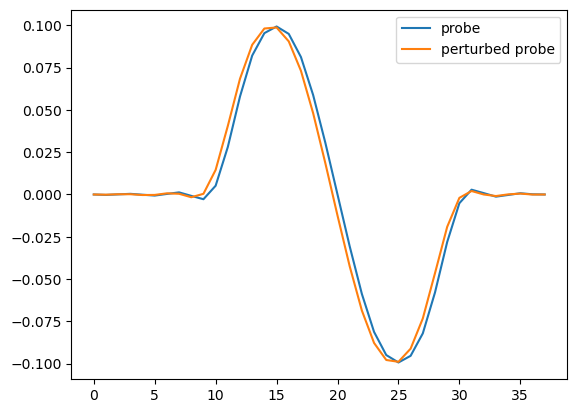

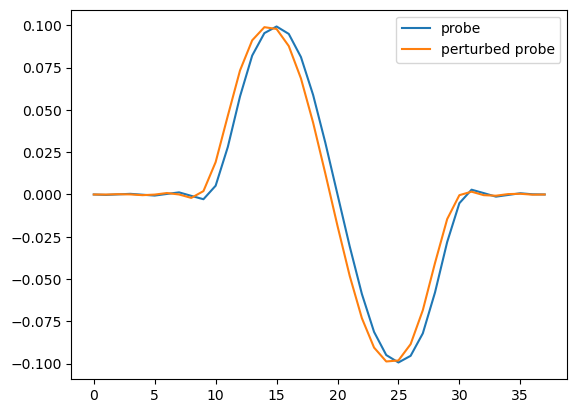

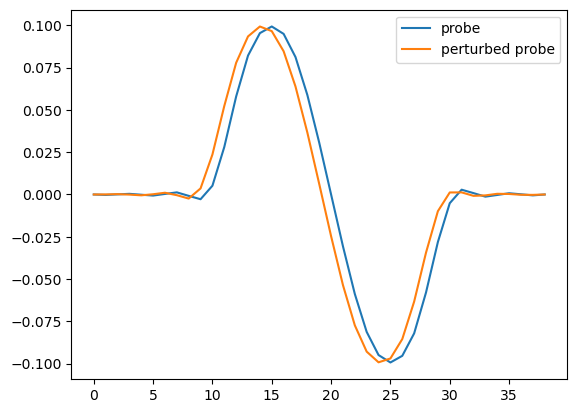

In [76]:
winlen=int(nper_probe/2+10)
print(winlen)

ii=0
itstart=int(50+nper_probe/2)
while itstart < nt:
    plt.figure()
    
    sig1=sigprobe[itstart-winlen:itstart+winlen]
    sig3=sigprobe_pert[itstart-winlen:itstart+winlen]+sigPUMP[itstart-winlen:itstart+winlen]
    sig2=sigPUMP[itstart-winlen:itstart+winlen]
    tplot=t[itstart-winlen:itstart+winlen]
    itstart=itstart+nper_pulse

    tshift[ii]=compdelay(tplot,sig1,sig2,sig3,winlen=10)
    ii=ii+1
    #plt.plot(tplot,sig1)
    #plt.plot(tplot,sig2)
    #plt.plot(tplot,sig3)


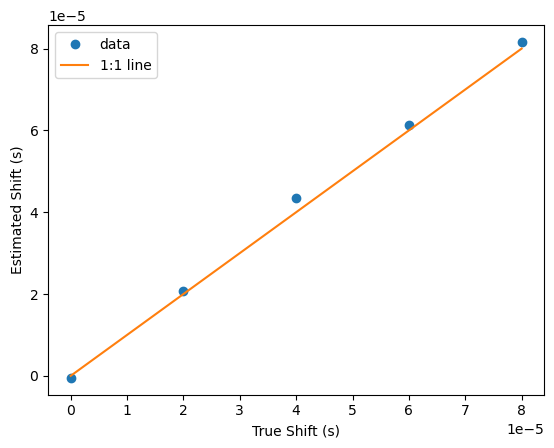

In [81]:
plt.plot(tshift_true,tshift*1e3,'o',label='data')
plt.plot([0,np.max(tshift_true)],[0,np.max(tshift_true)],label='1:1 line')
plt.xlabel('True Shift (s)')
plt.ylabel('Estimated Shift (s)')
plt.legend()